In [1]:
import os
print(os.getcwd())

C:\Users\bagde\OneDrive\Desktop\Mutual_Fund_Analytics\notebooks


In [2]:
import pandas as pd

df = pd.read_csv("../Data/processed/mutual_fund_nav.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
df.head()

,Scheme_Code,ISIN_Div_Payout,ISIN_Div_Reinvestment,Scheme_Name,NAV,Date
0,119551,INF209KA12Z1,INF209KA13Z9,Aditya Birla Sun Life Banking & PSU Debt Fund ...,105.9219,19-Jun-2026
1,119552,INF209K01YM2,-,Aditya Birla Sun Life Banking & PSU Debt Fund ...,117.0754,19-Jun-2026
2,119553,INF209K01YO8,-,Aditya Birla Sun Life Banking & PSU Debt Fund ...,103.9719,19-Jun-2026
3,108272,INF209K01LX6,INF209KA11Z3,Aditya Birla Sun Life Banking & PSU Debt Fund ...,148.2960,19-Jun-2026
4,110282,INF209K01LU2,-,Aditya Birla Sun Life Banking & PSU Debt Fund ...,112.3932,19-Jun-2026


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14219 entries, 0 to 14218
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Scheme_Code            14219 non-null  int64  
 1   ISIN_Div_Payout        14219 non-null  object 
 2   ISIN_Div_Reinvestment  14219 non-null  object 
 3   Scheme_Name            14219 non-null  object 
 4   NAV                    14219 non-null  float64
 5   Date                   14219 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 666.6+ KB


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14219 entries, 0 to 14218
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Scheme_Code            14219 non-null  int64         
 1   ISIN_Div_Payout        14219 non-null  object        
 2   ISIN_Div_Reinvestment  14219 non-null  object        
 3   Scheme_Name            14219 non-null  object        
 4   NAV                    14219 non-null  float64       
 5   Date                   14219 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 666.6+ KB


In [6]:
df.describe()

,Scheme_Code,NAV,Date
count,14219.000000,1.421900e+04,14219
mean,137225.351502,1.646905e+03,2024-01-20 18:01:35.702932480
min,100033.000000,0.000000e+00,2008-10-02 00:00:00
25%,126030.500000,1.118630e+01,2021-05-24 00:00:00
50%,142283.000000,1.318900e+01,2026-06-19 00:00:00
75%,149797.500000,3.061405e+01,2026-06-19 00:00:00
max,154426.000000,2.458146e+06,2026-06-21 00:00:00
std,15259.488247,5.262180e+04,NaN


In [7]:
df.isnull().sum()

Scheme_Code              0
ISIN_Div_Payout          0
ISIN_Div_Reinvestment    0
Scheme_Name              0
NAV                      0
Date                     0
dtype: int64

In [8]:
print("Total Schemes :", df["Scheme_Name"].nunique())

Total Schemes : 14219


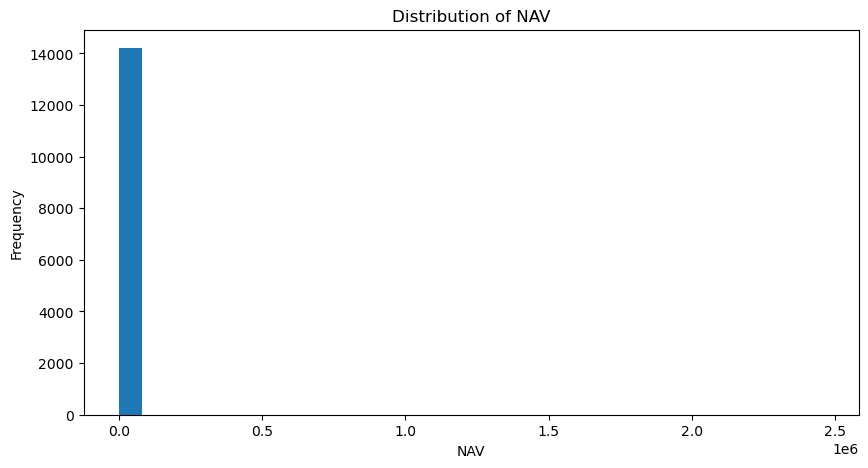

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["NAV"], bins=30)
plt.title("Distribution of NAV")
plt.xlabel("NAV")
plt.ylabel("Frequency")
plt.show()

In [10]:
top10 = df.sort_values("NAV", ascending=False).head(10)

top10[["Scheme_Name","NAV"]]

,Scheme_Name,NAV
11632,IL&FS Infrastructure Debt Fund Series 2B - Gro...,2.458146e+06
11633,IL&FS Infrastructure Debt Fund Series 2C - Gro...,2.424611e+06
11630,IL&FS Infrastructure Debt Fund Series 1C- Divi...,2.185944e+06
11629,IL&FS Infrastructure Debt Fund Series 1C - Growth,2.185944e+06
11631,IL&FS Infrastructure Debt Fund Series 2A - Gro...,1.903364e+06
11627,IL&FS Infrastructure Debt Fund Series 1A - Div...,1.680494e+06
11628,IL&FS Infrastructure Debt Fund Series 1A - Growth,1.680494e+06
11638,IL&FS Infrastructure Debt Fund Series 1B - Growth,1.456757e+06
11637,IL&FS Infrastructure Debt Fund Series 1B - Div...,1.456757e+06
11635,IL&FS Infrastructure Debt Fund Series 3A - Gro...,1.213045e+06


In [11]:
lowest10 = df.sort_values("NAV").head(10)

lowest10[["Scheme_Name","NAV"]]

,Scheme_Name,NAV
2046,Nippon India Medium Duration Fund - Segregate...,0.0
418,Baroda BNP Paribas Credit risk fund -Defunct -...,0.0
417,Baroda BNP Paribas Credit Risk fund - Regular-...,0.0
416,Baroda BNP Paribas Credit Risk fund - Regular-...,0.0
662,Franklin India Dynamic Accrual Fund- Segregate...,0.0
663,Franklin India Dynamic Accrual Fund- Segregate...,0.0
664,Franklin India Dynamic Accrual Fund- Segregate...,0.0
665,Franklin India Dynamic Accrual Fund- Segregate...,0.0
666,Franklin India Dynamic Accrual Fund- Segregate...,0.0
668,Franklin India Dynamic Accrual Fund-Segregated...,0.0


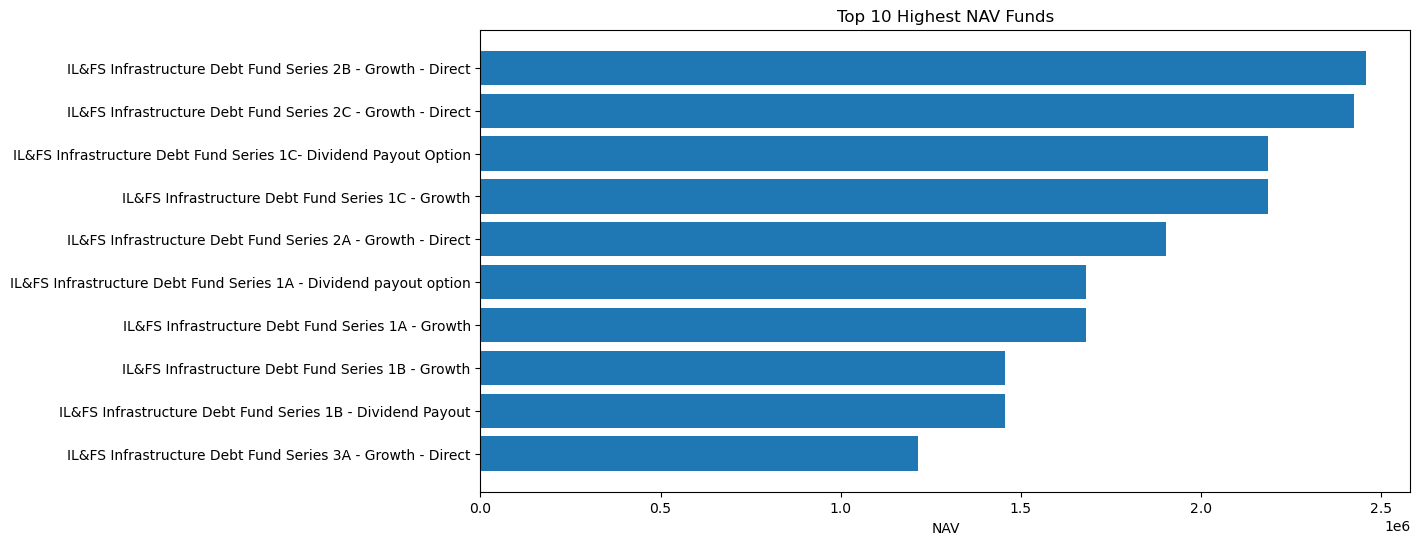

In [12]:
import matplotlib.pyplot as plt

top10 = df.sort_values("NAV", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top10["Scheme_Name"], top10["NAV"])
plt.xlabel("NAV")
plt.title("Top 10 Highest NAV Funds")
plt.gca().invert_yaxis()
plt.show()

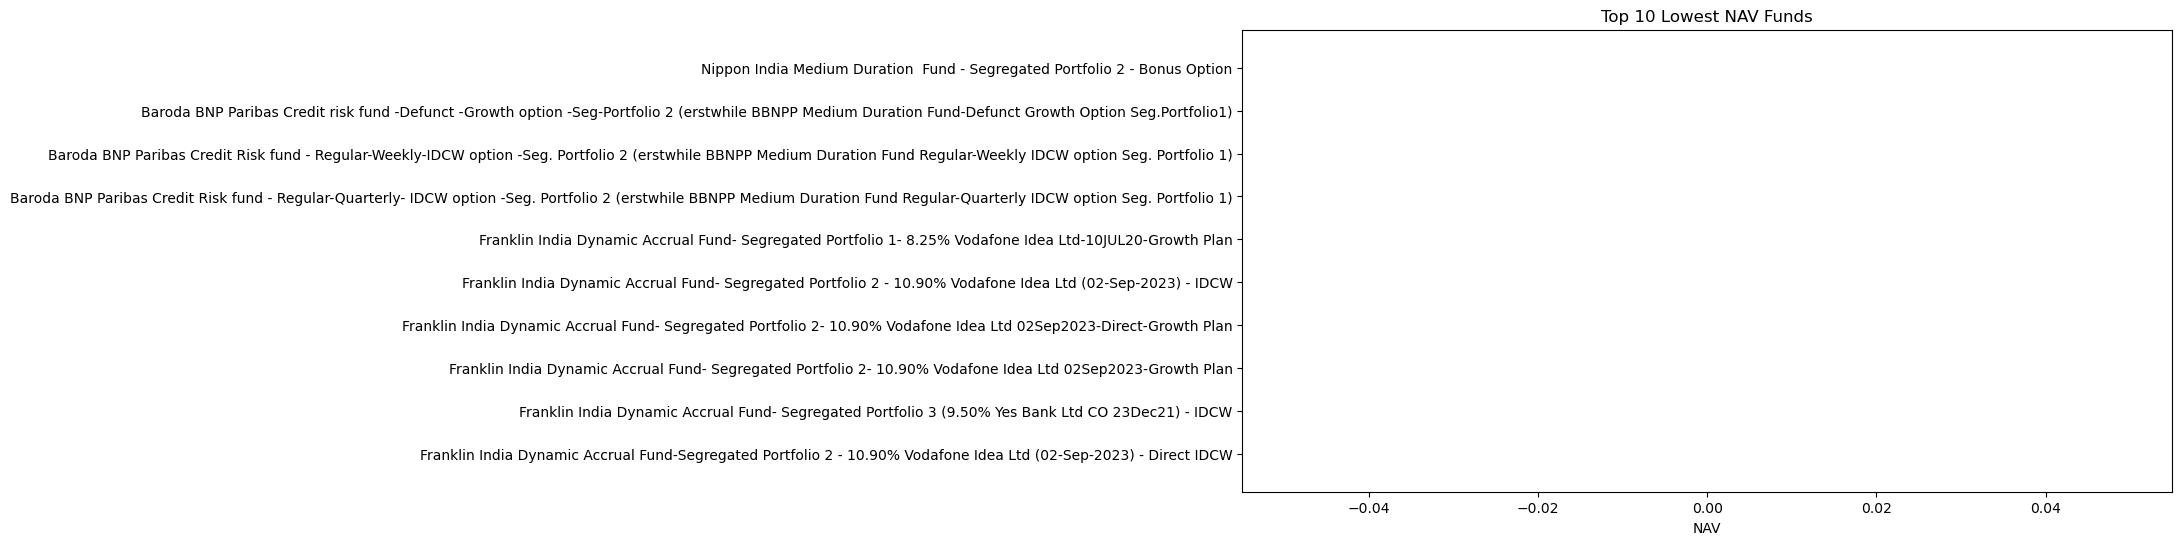

In [13]:
plt.figure(figsize=(12,6))
plt.barh(lowest10["Scheme_Name"], lowest10["NAV"])
plt.xlabel("NAV")
plt.title("Top 10 Lowest NAV Funds")
plt.gca().invert_yaxis()
plt.show()

In [14]:
print("Average NAV :", df["NAV"].mean())

Average NAV : 1646.9054354407835


In [15]:
print("Minimum NAV :", df["NAV"].min())

Minimum NAV : 0.0


In [16]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [17]:
print("Total Unique Schemes :", df["Scheme_Name"].nunique())

Total Unique Schemes : 14219


In [18]:
df["Scheme_Name"].value_counts().head(10)

Scheme_Name
Aditya Birla Sun Life Banking & PSU Debt Fund  - DIRECT - IDCW                                                         1
SBI Long Term Advantage Fund Series V - Regular Plan - Growth                                                          1
SBI Long Term Advantage Fund - Series III - Direct Plan - Growth                                                       1
SBI Long Term Advantage Fund - Series III - Direct Plan - Income Distribution cum Capital Withdrawal Option (IDCW)     1
SBI Long Term Advantage Fund - Series III - Regular Plan - Growth                                                      1
SBI Long Term Advantage Fund - Series III - Regular Plan - Income Distribution cum Capital Withdrawal Option (IDCW)    1
SBI Long Term Advantage Fund - Series IV - Direct Plan - Growth                                                        1
SBI Long Term Advantage Fund - Series IV - Direct Plan - Income Distribution cum Capital Withdrawal Option (IDCW)      1
SBI Long Term Advant

In [19]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14219 entries, 0 to 14218
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Scheme_Code            14219 non-null  int64         
 1   ISIN_Div_Payout        14219 non-null  object        
 2   ISIN_Div_Reinvestment  14219 non-null  object        
 3   Scheme_Name            14219 non-null  object        
 4   NAV                    14219 non-null  float64       
 5   Date                   14219 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 666.6+ KB


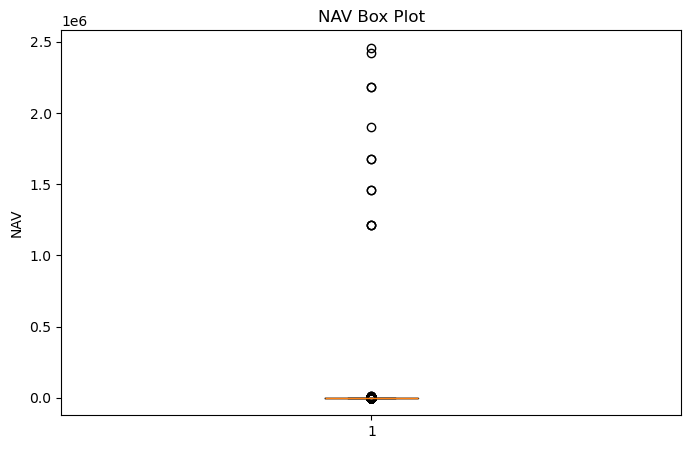

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["NAV"])
plt.title("NAV Box Plot")
plt.ylabel("NAV")
plt.show()

In [21]:
df.to_csv("../data/processed/clean_mutual_fund_nav.csv", index=False)

print("Saved Successfully")

Saved Successfully


In [24]:
cd C:\Users\bagde\OneDrive\Desktop\Mutual_Fund_Analytics

git add .
git commit -m "Completed Day 2 EDA"
git push

SyntaxError: invalid syntax (2477325367.py, line 1)

In [25]:
cd C:\Users\bagde\OneDrive\Desktop\Mutual_Fund_Analytics

git add .

git commit -m "Completed Day 2 EDA"

git push

SyntaxError: invalid syntax (3560687107.py, line 1)

In [26]:
!git add .
!git commit -m "Completed Day 2 EDA"
!git push

[main c90ad9a] Completed Day 2 EDA
 2 files changed, 913 insertions(+)
 create mode 100644 notebooks/.ipynb_checkpoints/EDA_Analysis-checkpoint.ipynb
 create mode 100644 notebooks/EDA_Analysis.ipynb


To https://github.com/bagdepurushottam50-bit/Mutual_Fund_Analytics.git
   3c3f7b4..c90ad9a  main -> main


In [28]:
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        print(os.path.join(root, file))

../data\data_ingestion.py.ipynb
../data\.ipynb_checkpoints\data_ingestion.py-checkpoint.ipynb
../data\processed\clean_mutual_fund_nav.csv
../data\processed\mutual_fund_nav.csv
../data\raw\nav_data.txt


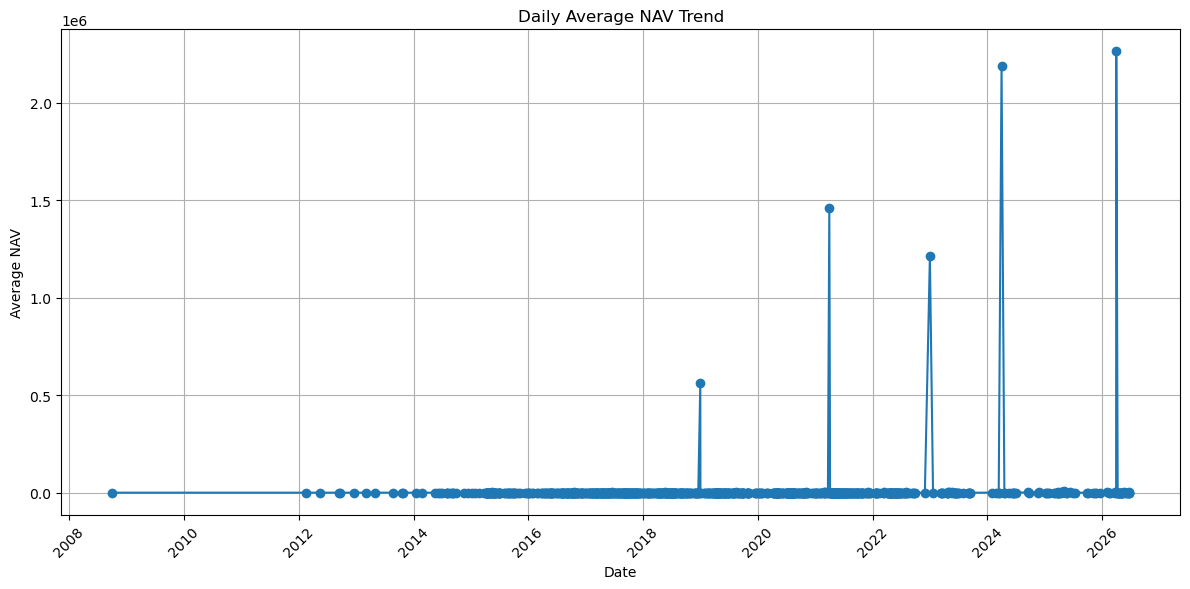

In [29]:
import matplotlib.pyplot as plt

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Daily Average NAV
daily_nav = df.groupby("Date")["NAV"].mean()

plt.figure(figsize=(12,6))
plt.plot(daily_nav.index, daily_nav.values, marker="o")
plt.title("Daily Average NAV Trend")
plt.xlabel("Date")
plt.ylabel("Average NAV")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

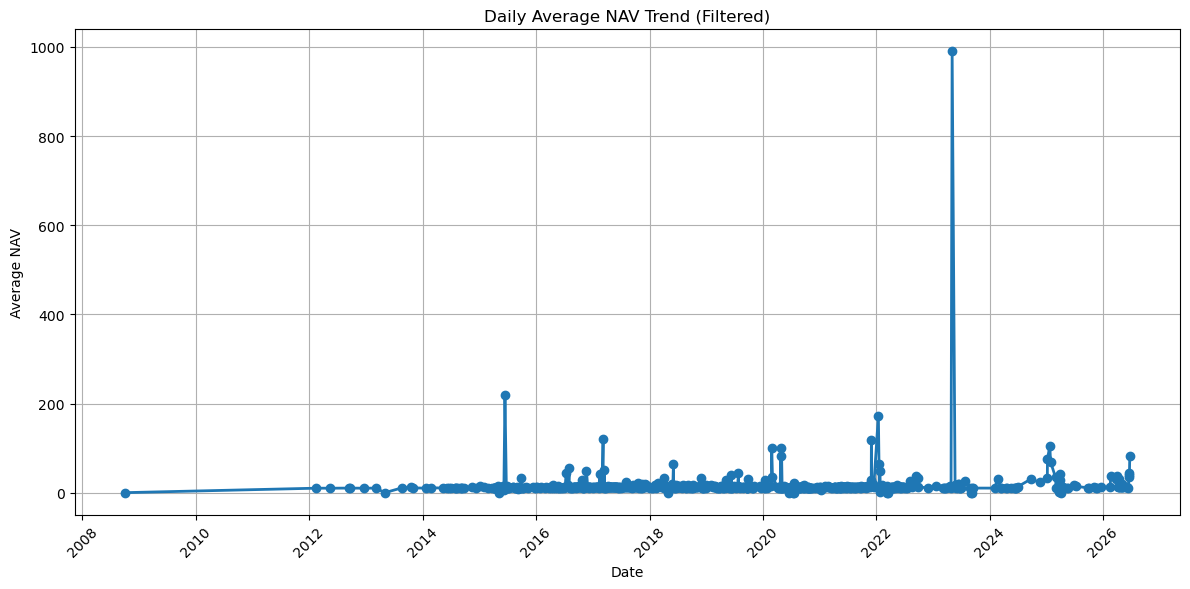

In [30]:
# Remove very high NAV values (Outliers)

filtered_df = df[df["NAV"] < 1000]

daily_nav = filtered_df.groupby("Date")["NAV"].mean()

plt.figure(figsize=(12,6))
plt.plot(daily_nav.index, daily_nav.values,
         marker="o", linewidth=2)

plt.title("Daily Average NAV Trend (Filtered)")
plt.xlabel("Date")
plt.ylabel("Average NAV")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

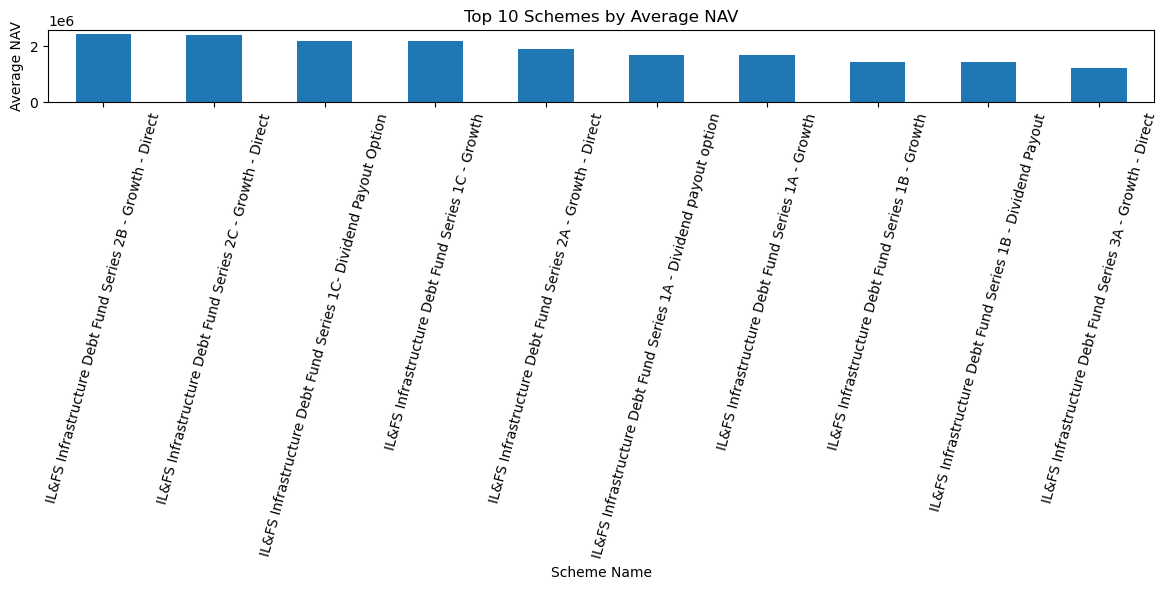

In [31]:
top10 = df.groupby("Scheme_Name")["NAV"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top10.plot(kind="bar")

plt.title("Top 10 Schemes by Average NAV")
plt.xlabel("Scheme Name")
plt.ylabel("Average NAV")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()